[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd6-pm/new_nb_09_03_evaluation_results_discussion.ipynb)

# new_nb_09_03. Evaluation, results, and discussion

**Notebook 4 of 4, Idea 9 arm 2.** This is where the verdict is issued.

**What the previous three notebooks settled.**

`new_nb_09_00` fixed the question, the endpoint and the decision rule in a file before any data was
seen. The endpoint is **rho**, the normalised mirror-consistency residual, where **0 is an exact sign
flip and therefore perfect mirror equivariance and the best value, 2 is unrelated, and 4 is fully
mirror-symmetric and therefore completely mirror-blind and the worst value**. The **anatomical mirror**
`M` reflects the body and swaps left and right landmark identities. rho is label-free and
parameter-free, which is why it can be used on a cohort where a labelled endpoint could not. Credit
requires **all three** registered conditions: the improvement must exceed the control's seed spread, the
paired-by-source bootstrap interval must exclude zero, and no registered guardrail may fall by more than
the control's seed spread. Registered guardrails: `feature_std`, `mean_pair_cosine`, and a source-grouped
five-class balanced accuracy. Registered seeds: 0 through 4.

`new_nb_09_01` established on synthetic fixtures that the head-only form of the term is an exact no-op,
that the registered `absolute` form satisfies itself by shrinking the readout rather than changing the
encoder, and that the scale-invariant `parameter_free` form does move rho. It also verified rho's scale
against encoders built by hand to read exactly 0 and exactly 4.

`new_nb_09_02` trained the real ladder: control rung D0 at weight 0.0 and treatment rung E1 at weight
0.02 with variant `parameter_free`, full five-stage curriculum, 600 epochs and 11,400 optimizer updates
per rung, on **3 seeds against the 5 registered**. It reported the trajectories and deliberately drew no
conclusion.

**What this notebook answers.** Four questions, in this order.

1. Did the equivariance term change the encoder on real data, measured on the primary endpoint?
2. Does that change exceed what seed-to-seed variation produces on its own?
3. Did anything get worse: representation spread, condition geometry, or a grouped condition probe?
4. What does the answer license us to claim, and what does it not?

**What it assumes you already have.** The six checkpoints and JSONs written by `new_nb_09_02`, and the
contract file written by `new_nb_09_00`. It trains nothing, so it can be rerun and audited without
spending compute.

**The order of this notebook is itself part of the method.** The rule is restated from the contract file
*before* any result is loaded. Then the endpoints are recomputed. Then the rule is applied mechanically.
Writing it the other way round, with the numbers already visible while the thresholds are being read,
is how a preregistration quietly turns into a story.

Everything here reads saved checkpoints, so any disagreement between the numbers printed in this
notebook and the numbers printed during training is itself a finding worth chasing rather than a
nuisance. Section 2 checks for exactly that.

**Research use only.** Folder labels are dataset annotations, not clinical diagnoses. All results are
transductive: the encoder saw every evaluation sequence during training, on both rungs equally.


In [1]:
from pathlib import Path
import os, sys, json, math, hashlib, copy, time, warnings

import numpy as np
import pandas as pd

RANDOM_SEED = 42


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"
try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

TRUTHY = {"1", "true", "yes", "on"}
REQUESTED_MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
INCLUDE_AUGMENTED = os.getenv("SJEPA_INCLUDE_AUGMENTED_NORMAL", "0").strip().lower() in TRUTHY
ARTIFACT_ROOT = Path(os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")).expanduser()
CACHE_DIR = Path(os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")).expanduser()
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

# The six authorised left/right pairs the head, the signed target, and rho are all built from.
LEFT_RIGHT_PAIRS = [(11, 12), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]
# The full 16-pair anatomical mirror, matching notebook 04's geometric_view flip.
FULL_MIRROR_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),
    (11, 12), (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]

# Arm-2 output lives in its own directory. Nothing here ever writes a baseline artifact name.
ARM2_DIR_NAME = "idea9_arm2"
BASELINE_CHECKPOINT_NAME = (
    "sjepa_curriculum_final_augmented.pt" if INCLUDE_AUGMENTED else "sjepa_curriculum_final.pt"
)


def artifact_dir_for(mode):
    return ARTIFACT_ROOT / mode

MODE = REQUESTED_MODE if REQUESTED_MODE in {"smoke", "real"} else "smoke"
ARTIFACT_DIR = artifact_dir_for(MODE)
ARM2_DIR = ARTIFACT_DIR / ARM2_DIR_NAME

CONTRACT_PATH = ARM2_DIR / "idea9_arm2_contract.json"
if not CONTRACT_PATH.is_file():
    raise FileNotFoundError(f"Run new_nb_09_00 first: {CONTRACT_PATH} is missing")
CONTRACT = json.loads(CONTRACT_PATH.read_text())
PRE_REGISTERED = CONTRACT["pre_registered"]

print("The rule, restated from the contract file BEFORE any result is loaded:")
print(f"  primary endpoint : {PRE_REGISTERED['primary_endpoint']['name']}")
print(f"  scale            : {PRE_REGISTERED['primary_endpoint']['scale']}")
for key, text in PRE_REGISTERED["credit_rule"].items():
    if key != "all_three_required":
        print(f"  {key:32s} {text}")
print(f"  guardrails       : {', '.join(PRE_REGISTERED['guardrails'])}")
print(f"\n  registered seeds : {PRE_REGISTERED['ladder']['seeds']}")

The rule, restated from the contract file BEFORE any result is loaded:
  primary endpoint : rho_target_encoder
  scale            : 0 = exact sign flip (best), 2 = unrelated, 4 = fully symmetric (worst)
  1_exceeds_seed_spread            mean(rho_D0) - mean(rho_E1) > std(rho_D0) across seeds
  2_paired_bootstrap               paired-by-source bootstrap CI for the improvement excludes zero
  3_no_guardrail_regression        no guardrail falls by more than the D0 seed spread
  guardrails       : feature_std, mean_pair_cosine, source_grouped_five_class_balanced_accuracy

  registered seeds : [0, 1, 2, 3, 4]


In [2]:
import torch
from torch import nn
from torch.nn import functional as F


class SkeletonPatchEncoder(nn.Module):
    def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                 embed_dim=64, depth=2, heads=4, dropout=0.0):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames, self.joints = frames, joints
        self.coordinate_dim, self.segment_length = coordinate_dim, segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(batch, self.segments, self.segment_length, joints, channels)
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept = keep_mask.sum(dim=1)
            if not torch.equal(kept, kept[:1].expand_as(kept)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(self, segments, joints, encoder_dim=64, predictor_dim=64,
                 depth=2, heads=4, dropout=0.0):
        super().__init__()
        self.segments, self.joints = segments, joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim, nhead=heads, dim_feedforward=predictor_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(batch, self.segments * self.joints, -1).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (self.time_pos[:, None, :] + self.joint_pos[None, :, :]).reshape(
            1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                 embed_dim=64, encoder_depth=2, predictor_depth=2, heads=4):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length, embed_dim, encoder_depth, heads)
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments, joints, embed_dim, embed_dim, predictor_depth, heads)
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(len(target), -1, all_targets.shape[-1])
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
                self.target_encoder.parameters(), self.view_encoder.parameters()):
            target_parameter.mul_(momentum).add_(view_parameter, alpha=1.0 - momentum)

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        self.target_center.mul_(beta).add_(targets.mean(dim=(0, 1)), alpha=1.0 - beta)


def sjepa_cross_entropy(predicted, targets, center,
                        predictor_temperature=0.10, target_temperature=0.06):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature, dim=-1).detach()
    prediction_log_prob = torch.log_softmax(predicted / predictor_temperature, dim=-1)
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0

def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (np.arange(1, gap + 1, dtype=np.float32) / (gap + 1))[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction)
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    both = left_ok & right_ok
    pelvis[both] = 0.5 * (left_hip[both] + right_hip[both])
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0)
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:])


def prepare_sequence(raw_sequence, frames):
    """raw_sequence: [T, 33, 4] -> (xyz [frames, 33, 3] float32, valid [frames, 33] bool)."""
    interpolated, valid = interpolate_low_visibility(raw_sequence)
    scaled = center_and_scale(interpolated)
    xyz = temporal_resize(scaled[..., :3], frames)
    valid_resized = temporal_resize(valid.astype(np.float32), frames) > 0.5
    return xyz.astype(np.float32), valid_resized


def anatomical_mirror_raw(coords, pairs=FULL_MIRROR_PAIRS):
    """Mirror the RAW [T, 33, 4] column so the SAME preprocessing can be re-run on the reflection."""
    mirrored = np.asarray(coords, dtype=np.float32).copy()
    mirrored[:, :, 0] = -mirrored[:, :, 0]
    for left, right in pairs:
        mirrored[:, [left, right], :] = mirrored[:, [right, left], :]
    return mirrored


def signed_left_minus_right(coords):
    """Item 05's frozen target: signed per-side excursion, left minus right, on preprocessed coords."""
    coords = np.asarray(coords, dtype=np.float64)[..., :3]
    total = 0.0
    for left, right in LEFT_RIGHT_PAIRS:
        total += coords[:, left, :].std(axis=0).sum() - coords[:, right, :].std(axis=0).sum()
    return float(total)

def anatomical_mirror_coords(coords):
    """Reflect the RAW skeleton: negate the sideways x coordinate and swap each left/right landmark.

    coords: [B, FRAMES, 33, 3] tensor. Differentiable passthrough, so gradients flow through the mirror.
    """
    mirrored = coords.clone()
    mirrored[..., 0] = -mirrored[..., 0]
    index = list(range(33))
    for left, right in FULL_MIRROR_PAIRS:
        index[left], index[right] = right, left
    return mirrored[:, :, index, :]


class AntisymmetricHead(nn.Module):
    """s = sum over pairs of ( f(L) - f(R) ), with f shared across joints and sides.

    Difference only, so the head negates under a swap of its own inputs by construction. In Arm 2 the
    head's parameters are trainable and join the optimiser, so L_equiv can shape the encoder and the
    head together.
    """

    def __init__(self, embed_dim, out_dim=4, hidden=32, pairs=LEFT_RIGHT_PAIRS):
        super().__init__()
        self.pairs = list(pairs)
        self.f = nn.Sequential(nn.Linear(embed_dim, hidden), nn.GELU(), nn.Linear(hidden, out_dim))

    def per_joint_feature(self, tokens):
        return tokens.mean(dim=1)

    def s_from_perjoint(self, per_joint):
        out = 0.0
        for left, right in self.pairs:
            out = out + (self.f(per_joint[:, left, :]) - self.f(per_joint[:, right, :]))
        return out

    def forward(self, tokens):
        return self.s_from_perjoint(self.per_joint_feature(tokens))

    def swapped(self, tokens):
        """Wiring self-check only. Returns -forward(tokens) by construction, so it trains nothing."""
        per_joint = self.per_joint_feature(tokens)
        swapped = per_joint.clone()
        for left, right in self.pairs:
            swapped[:, left, :] = per_joint[:, right, :]
            swapped[:, right, :] = per_joint[:, left, :]
        return self.s_from_perjoint(swapped)


def encoder_tokens_for_head(view_encoder, coords, segments, joints, embed_dim):
    return view_encoder(coords).reshape(len(coords), segments, joints, embed_dim)


def mirror_pair_signals(readout, view_encoder, coords, segments, embed_dim, joints=33):
    """Return ( s(enc(x)), s(enc(Mx)) ) with M the anatomical mirror on the RAW skeleton.

    The mirror is applied to raw coordinates and BOTH versions are run through the view encoder. A
    head-only token swap would be identically zero for every input and every parameter, so it would train
    nothing at all. Going through the encoder makes the residual a genuine constraint on encoder weights.
    """
    tokens = encoder_tokens_for_head(view_encoder, coords, segments, joints, embed_dim)
    tokens_mirrored = encoder_tokens_for_head(
        view_encoder, anatomical_mirror_coords(coords), segments, joints, embed_dim)
    return readout(tokens), readout(tokens_mirrored)


def equivariance_loss_absolute(head, view_encoder, coords, segments, embed_dim, joints=33):
    """nb_09b's term exactly as written: L = mean( ( s(enc(Mx)) + s(enc(x)) )^2 ).

    This has a degenerate solution. Because the head is trainable and shares the objective, the cheapest
    way to shrink the squared residual is to shrink s itself, which costs the encoder nothing. Notebook 01
    measures that collapse happening, which is why this variant is kept only as the documented baseline
    for comparison and is not used for the real ladder.
    """
    s, s_mirrored = mirror_pair_signals(head, view_encoder, coords, segments, embed_dim, joints)
    return ((s_mirrored + s) ** 2).mean()


def equivariance_loss_normalized(head, view_encoder, coords, segments, embed_dim,
                                 joints=33, eps=1e-6):
    """The scale-invariant repair, with the trainable head retained.

    L = mean_seq [ ||s(enc(Mx)) + s(enc(x))||^2 / ( 0.5 * (||s(enc(x))||^2 + ||s(enc(Mx))||^2) + eps ) ]

    Dividing by the signal's own magnitude removes the shrink-the-head escape route: scaling s by any
    constant leaves the ratio unchanged, so the only way down is for the encoder to actually represent the
    mirrored body as the sign flip of the original. Still label-free.
    """
    s, s_mirrored = mirror_pair_signals(head, view_encoder, coords, segments, embed_dim, joints)
    numerator = ((s_mirrored + s) ** 2).sum(dim=1)
    denominator = 0.5 * ((s ** 2).sum(dim=1) + (s_mirrored ** 2).sum(dim=1))
    return (numerator / (denominator + eps)).mean()


def equivariance_loss_parameter_free(view_encoder, coords, segments, embed_dim,
                                     joints=33, eps=1e-6):
    """The same scale-invariant residual with the head replaced by the identity feature map.

    This removes the head from the objective entirely, so there are no readout parameters that could be
    tuned to flatter the term. Its aggregation is a mean of per-sequence ratios, whereas the reported
    endpoint rho is a ratio of sums over the whole cohort, so the two are related but not identical.
    """
    s, s_mirrored = mirror_pair_signals(
        antisymmetric_contraction, view_encoder, coords, segments, embed_dim, joints)
    numerator = ((s_mirrored + s) ** 2).sum(dim=1)
    denominator = 0.5 * ((s ** 2).sum(dim=1) + (s_mirrored ** 2).sum(dim=1))
    return (numerator / (denominator + eps)).mean()


EQUIVARIANCE_VARIANTS = {
    "absolute": "nb_09b as written; has a shrink-the-head degenerate solution",
    "normalized": "scale-invariant, trainable head retained",
    "parameter_free": "scale-invariant, head removed from the objective",
}


def equivariance_term(variant, head, view_encoder, coords, segments, embed_dim, joints=33):
    """Dispatch to one equivariance variant, so a rung records which form it optimised."""
    if variant == "absolute":
        return equivariance_loss_absolute(head, view_encoder, coords, segments, embed_dim, joints)
    if variant == "normalized":
        return equivariance_loss_normalized(head, view_encoder, coords, segments, embed_dim, joints)
    if variant == "parameter_free":
        return equivariance_loss_parameter_free(view_encoder, coords, segments, embed_dim, joints)
    raise ValueError(f"unknown equivariance variant {variant!r}")


# --- the pre-registered PRIMARY endpoint: parameter-free, label-free, no fitting ----------------
def antisymmetric_contraction(tokens):
    """T(tokens) = sum over authorised pairs of ( tok_L - tok_R ) after a per-joint time mean.

    This is the AntisymmetricHead with f set to the identity, so it has no parameters at all. That makes
    it comparable across checkpoints without fitting anything and without a label.
    tokens: [B, SEGMENTS, 33, D] -> [B, D]
    """
    per_joint = tokens.mean(dim=1)
    out = 0.0
    for left, right in LEFT_RIGHT_PAIRS:
        out = out + (per_joint[:, left, :] - per_joint[:, right, :])
    return out


@torch.no_grad()
def mirror_residual_terms(encoder, xyz, segments, embed_dim, device, batch_size=16):
    """Per-sequence numerator and denominator of the normalised mirror-consistency residual rho.

    rho = mean_seq || T(enc(Mx)) + T(enc(x)) ||^2
        / mean_seq ( 0.5 * ( || T(enc(x)) ||^2 + || T(enc(Mx)) ||^2 ) )

    Scale, which is what makes rho readable without a target: rho = 0 means the encoder represents the
    mirrored body as the exact sign flip of the original along this axis, rho = 2 means the two are
    unrelated, and rho = 4 means the encoder is fully symmetric and cannot tell a body from its mirror.
    Lower is more mirror-honest. Returned per sequence so results can be aggregated by source video.
    """
    numerators, denominators = [], []
    for start in range(0, len(xyz), batch_size):
        chunk = torch.tensor(xyz[start:start + batch_size], dtype=torch.float32, device=device)
        tokens = encoder(chunk).reshape(len(chunk), segments, 33, embed_dim)
        tokens_mirrored = encoder(anatomical_mirror_coords(chunk)).reshape(
            len(chunk), segments, 33, embed_dim)
        s = antisymmetric_contraction(tokens)
        s_mirrored = antisymmetric_contraction(tokens_mirrored)
        numerators.append(((s_mirrored + s) ** 2).sum(dim=1).cpu().numpy())
        denominators.append((0.5 * ((s ** 2).sum(dim=1) + (s_mirrored ** 2).sum(dim=1))).cpu().numpy())
    return np.concatenate(numerators), np.concatenate(denominators)


def rho_from_terms(numerators, denominators):
    total = float(np.sum(denominators))
    if total <= 0:
        return float("nan")
    return float(np.sum(numerators) / total)


@torch.no_grad()
def head_signal_scale(head, encoder, xyz, segments, embed_dim, device, batch_size=16):
    """Mean ||s|| over the cohort. Evidence for or against the shrink-the-head degenerate solution."""
    norms = []
    for start in range(0, len(xyz), batch_size):
        chunk = torch.tensor(xyz[start:start + batch_size], dtype=torch.float32, device=device)
        tokens = encoder(chunk).reshape(len(chunk), segments, 33, embed_dim)
        norms.append(head(tokens).norm(dim=1).cpu().numpy())
    return float(np.mean(np.concatenate(norms)))

def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, with no motion score. Verbatim from notebook 04."""
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for index in range(len(mask)):
        candidates = np.flatnonzero(eligible[index].reshape(-1))
        mask[index].reshape(-1)[rng.choice(candidates, size=n_mask, replace=False)] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    if mask[:, :, forbidden].any():
        raise AssertionError("A forbidden keypoint entered the target mask")
    return mask


def geometric_view(x, max_degrees=8.0, translate=0.03, flip_probability=0.0):
    """Notebook 04's augmentation: y-axis rotation mixing x and z, plus a small translation.

    flip_probability stays 0.0 exactly as in notebook 04. Turning the flip on would put mirrored bodies
    into the JEPA branch itself, which would confound the equivariance term with a data augmentation.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (torch.rand(batch, device=x.device) * 2.0 - 1.0) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x, original_z = view[..., 0].clone(), view[..., 2].clone()
    view[..., 0] = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    view[..., 2] = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., :2] += (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    if flip_probability > 0:
        raise ValueError("The flip augmentation must stay off; it would confound L_equiv")
    return view.masked_fill(~present[..., None], 0.0)


def authorized_pool(tokens, valid_patch):
    """Pool only valid tokens from the 12 authorised landmarks. Verbatim from notebook 04."""
    batch, segments, _, dimension = tokens.shape
    selected = tokens[:, :, MASK_KEYPOINTS].reshape(batch, -1, dimension)
    weights = valid_patch[:, :, MASK_KEYPOINTS].reshape(batch, -1).to(tokens.dtype)
    denominator = weights.sum(dim=1, keepdim=True).clamp_min(1.0)
    return (selected * weights.unsqueeze(-1)).sum(dim=1) / denominator


def off_diagonal(matrix):
    n, m = matrix.shape
    if n != m:
        raise ValueError("Covariance matrix must be square")
    return matrix.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()


def vicreg_terms(first, second, gamma=1.0, eps=1e-4):
    """VICReg invariance, variance hinge, and off-diagonal covariance. Verbatim from notebook 04."""
    invariance = F.mse_loss(first, second)
    first_std = torch.sqrt(first.var(dim=0, unbiased=False) + eps)
    second_std = torch.sqrt(second.var(dim=0, unbiased=False) + eps)
    variance = 0.5 * (F.relu(gamma - first_std).mean() + F.relu(gamma - second_std).mean())
    first_centered = first - first.mean(dim=0)
    second_centered = second - second.mean(dim=0)
    denominator = max(len(first) - 1, 1)
    first_cov = first_centered.T @ first_centered / denominator
    second_cov = second_centered.T @ second_centered / denominator
    covariance = (off_diagonal(first_cov).square().sum()
                  + off_diagonal(second_cov).square().sum()) / (2.0 * first.shape[1])
    return 25.0 * invariance + 25.0 * variance + covariance, invariance, variance, covariance


def condition_group_terms(representations, condition_ids, margin=1.0):
    """Bounded compactness and centroid separation on unit vectors. Verbatim from notebook 04."""
    unique = torch.unique(condition_ids)
    zero = representations.sum() * 0.0
    if len(unique) < 2:
        return zero, zero, torch.tensor(float("nan"), device=representations.device)
    normalized = F.normalize(representations, dim=1)
    centroids = torch.stack([
        F.normalize(normalized[condition_ids == value].mean(dim=0), dim=0) for value in unique])
    compactness = torch.stack([
        (normalized[condition_ids == value] - centroids[index]).square().sum(dim=1).mean()
        for index, value in enumerate(unique)]).mean()
    pairwise = (centroids[:, None] - centroids[None, :]).square().sum(dim=-1).clamp_min(1e-12).sqrt()
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    return compactness, F.relu(margin - distances).square().mean(), distances.min()


def balanced_epoch_batches(data_by_condition, active_conditions, per_condition, rng):
    """Exhaustive, class-balanced replay batches for one epoch. Verbatim from notebook 04."""
    lengths = {c: len(data_by_condition[c]["xyz"]) for c in active_conditions}
    if min(lengths.values()) < 1:
        raise ValueError(f"Empty curriculum condition: {lengths}")
    steps = max(1, int(np.ceil(max(lengths.values()) / per_condition)))
    required = steps * per_condition
    orders = {}
    for condition in active_conditions:
        pieces = []
        while sum(len(piece) for piece in pieces) < required:
            pieces.append(rng.permutation(lengths[condition]))
        orders[condition] = np.concatenate(pieces)[:required]
    for step in range(steps):
        xyz_parts, valid_parts, label_parts = [], [], []
        for label, condition in enumerate(active_conditions):
            take = orders[condition][step * per_condition:(step + 1) * per_condition]
            xyz_parts.append(data_by_condition[condition]["xyz"][take])
            valid_parts.append(data_by_condition[condition]["valid"][take])
            label_parts.extend([label] * per_condition)
        permutation = rng.permutation(len(label_parts))
        yield (np.concatenate(xyz_parts)[permutation],
               np.concatenate(valid_parts)[permutation],
               np.asarray(label_parts, dtype=np.int64)[permutation])


class VICRegProjector(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dimension, dimension), nn.GELU(),
                                 nn.Linear(dimension, dimension))

    def forward(self, x):
        return self.net(x)


def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

POSE_CACHE_CONTRACT = json.loads((TUTORIAL_DIR / "pose_cache_contract.json").read_text())
COMPATIBLE_EXTRACTION_VERSIONS = frozenset(POSE_CACHE_CONTRACT["compatible_extraction_versions"])
COHORT_ROOT = PROJECT_ROOT / "data" / "gavd"
EXPECTED_SEQUENCE_COUNTS = {"normal": 12, "parkinsons": 9, "stroke": 12,
                            "myopathic": 47, "cerebralpalsy": 16}
EXPECTED_SEQUENCE_IDS = {
    condition: {path.stem for path in (COHORT_ROOT / condition).glob("*.csv")}
    for condition in CONDITIONS
}
MIN_AUGMENTED_NEURO_OBSERVED = 0.45


def canonical_pose_records(pose_dir, conditions=CONDITIONS):
    """Load the locked canonical pose cache with the same identity checks notebook 04 applies."""
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        available = {path.stem: path for path in folder.glob("*.npz")}
        expected = EXPECTED_SEQUENCE_IDS[condition]
        if set(available) != expected:
            raise ValueError(
                f"Canonical {condition} pose cache does not match the locked cohort at {folder}: "
                f"expected {len(expected)}, found {len(available)}")
        for sequence_id in sorted(expected):
            data = np.load(available[sequence_id], allow_pickle=False)
            version = str(data["extraction_version"].item())
            if version not in COMPATIBLE_EXTRACTION_VERSIONS:
                raise ValueError(f"Unsupported extraction version {version} in {available[sequence_id]}")
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape {sequence.shape}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "raw": sequence,
                "cohort": "canonical",
            })
    return records


def augmented_normal_records(artifact_dir):
    """Load the opt-in augmentation-normal cohort through its selection report, as notebook 04 does."""
    if not INCLUDE_AUGMENTED:
        return []
    folder = artifact_dir / "poses_augmented" / "normal"
    report_path = artifact_dir / "augmented_pose_extraction_report.csv"
    if not folder.exists() or not report_path.is_file():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is enabled but {folder} or {report_path} is missing. "
            "Run notes/migrate_augmented_pose_artifacts.py, or notes/annotate_normal_clips.py then "
            "notes/extract_augmented_poses.py.")
    report = pd.read_csv(report_path)
    candidates = report[~report["status"].astype(str).str.startswith("error")].copy()
    accepted = pd.to_numeric(candidates["neuro_observed"], errors="coerce") >= MIN_AUGMENTED_NEURO_OBSERVED
    selected = set(candidates.loc[accepted, "sequence_id"].astype(str))
    available = {path.stem: path for path in folder.glob("*.npz")}
    if set(available) != selected:
        raise ValueError("Augmented pose cache does not match its selection report")
    records = []
    for sequence_id in sorted(selected):
        data = np.load(available[sequence_id], allow_pickle=False)
        records.append({
            "condition": "normal",
            "sequence_id": str(data["sequence_id"].item()),
            "video_id": str(data["video_id"].item()),
            "raw": data["sequence"].astype(np.float32),
            "cohort": "augmented_normal",
        })
    return records


print("definitions loaded. Nothing in this notebook trains; the training helpers are imported because "
      "the guardrail geometry reuses notebook 04's pooling and centroid code verbatim.")

definitions loaded. Nothing in this notebook trains; the training helpers are imported because the guardrail geometry reuses notebook 04's pooling and centroid code verbatim.


## 1. Step 1 of 5. Load the cohort once, and the rungs that actually finished

**What we are about to do.** Load the evaluation cohort, and discover from disk which rungs are eligible
to be scored.

**Why the evaluation cohort is the canonical subset.** It is the 96 sequences carrying dataset
annotations, excluding the opt-in augmentation-normal pool that participates in training. That matches
arm 1's evaluation cohort, so the tertiary R-squared numbers reported later sit on the same ruler as arm
1's, and a reader can compare them without adjusting for cohort.

**Why rungs are discovered rather than assumed.** A rung counts only if its JSON exists, its checkpoint
exists, and its recorded epoch counts match the real profile of 300 plus 75. A rung interrupted
mid-curriculum is excluded and named. Silently averaging a half-trained rung into a control mean is
precisely the kind of error that produces a confident wrong answer, and the confidence would come from
the averaging rather than from the evidence.

**What to look at in the output.** Four things.

- The cohort line: **96 canonical sequences from 18 source videos**.
- The per-condition source counts: **normal 1, parkinsons 2, stroke 3, myopathic 10, cerebralpalsy 2**.
  This is the single most consequential row on the page. All 12 canonical normal sequences come from one
  video.
- The `NOTE` that follows it, which fires because of that row: a source-grouped condition probe cannot be
  built on this cohort. **This is a cohort fact, established here before any result has been loaded**,
  which is why it can never be mistaken for a reaction to an inconvenient number.
- The rung discovery lines: **6 completed rungs, seeds [0, 1, 2]**, and all three seeds usable for the
  paired comparison because both rungs completed for each.

**What we may conclude.** That there are three matched pairs to compare, and that one of the three
registered guardrails is going to be unmeasurable for a reason that has nothing to do with the treatment.

**What we may not conclude.** Anything about the result. No checkpoint has been opened yet.


In [3]:
FRAMES, SEGMENT_LENGTH, EMBED_DIM = 64, 4, 96
SEGMENTS = FRAMES // SEGMENT_LENGTH
ENCODER_DEPTH, PREDICTOR_DEPTH, HEADS = 4, 2, 4
REAL_NORMAL_EPOCHS, REAL_FINETUNE_EPOCHS = 300, 75
MODEL_CONFIG = {"frames": FRAMES, "joints": 33, "coordinate_dim": 3,
                "segment_length": SEGMENT_LENGTH, "embed_dim": EMBED_DIM,
                "encoder_depth": ENCODER_DEPTH, "predictor_depth": PREDICTOR_DEPTH, "heads": HEADS}

records = [r for r in canonical_pose_records(ARTIFACT_DIR / "poses") if r["cohort"] == "canonical"]
prepared = [prepare_sequence(r["raw"], FRAMES) for r in records]
EVAL_XYZ = np.stack([p[0] for p in prepared]).astype(np.float32)
EVAL_VALID = np.stack([p[1] for p in prepared])
EVAL_CONDITION = np.array([r["condition"] for r in records])
EVAL_VIDEO = np.array([r["video_id"] for r in records])
EVAL_Y = np.array([signed_left_minus_right(p[0]) for p in prepared], dtype=np.float64)

SOURCES_PER_CONDITION = {c: len(set(EVAL_VIDEO[EVAL_CONDITION == c])) for c in CONDITIONS}
GROUPED_PROBE_EVALUABLE = min(SOURCES_PER_CONDITION.values()) >= 2

print(f"evaluation cohort: {len(EVAL_XYZ)} canonical sequences, "
      f"{len(set(EVAL_VIDEO))} source videos")
print(pd.DataFrame({"sequences": pd.Series(EVAL_CONDITION).value_counts().reindex(CONDITIONS),
                    "source_videos": pd.Series(SOURCES_PER_CONDITION)}).to_string())
if not GROUPED_PROBE_EVALUABLE:
    print("\nNOTE: at least one condition has a single source video, so a source-grouped condition "
          "probe cannot be built. This is a cohort fact, known before any result is loaded.")

device = pick_device()
print(f"\ndevice: {device}")


def discovered_rungs():
    found, rejected = [], []
    for path in sorted(ARM2_DIR.glob("idea9_arm2_[DE]*_seed*.json")):
        bundle = json.loads(path.read_text())
        checkpoint = ARM2_DIR / bundle["checkpoint"]
        if not checkpoint.is_file():
            rejected.append((path.name, "checkpoint missing"))
            continue
        if (bundle.get("normal_epochs"), bundle.get("finetune_epochs")) != (
                REAL_NORMAL_EPOCHS, REAL_FINETUNE_EPOCHS):
            rejected.append((path.name, f"epochs {bundle.get('normal_epochs')}"
                                        f"/{bundle.get('finetune_epochs')} are not the real profile"))
            continue
        if len(bundle.get("completed_stages", [])) != 5:
            rejected.append((path.name, "curriculum incomplete"))
            continue
        found.append(bundle)
    return found, rejected


RUNGS, REJECTED = discovered_rungs()
for name, why in REJECTED:
    print(f"EXCLUDED {name}: {why}")
if not RUNGS:
    raise RuntimeError("No completed rung was found. Run new_nb_09_02 to completion first.")

OBSERVED_SEEDS = sorted({b["seed"] for b in RUNGS})
PAIRED_SEEDS = sorted({b["seed"] for b in RUNGS if b["rung"] == "D0"}
                      & {b["seed"] for b in RUNGS if b["rung"] == "E1"})
print(f"\ncompleted rungs : {len(RUNGS)}")
print(f"seeds observed  : {OBSERVED_SEEDS}")
print(f"seeds with BOTH rungs (usable for the paired comparison): {PAIRED_SEEDS}")

evaluation cohort: 96 canonical sequences, 18 source videos
               sequences  source_videos
normal                12              1
parkinsons             9              2
stroke                12              3
myopathic             47             10
cerebralpalsy         16              2

NOTE: at least one condition has a single source video, so a source-grouped condition probe cannot be built. This is a cohort fact, known before any result is loaded.

device: mps

completed rungs : 6
seeds observed  : [0, 1, 2]
seeds with BOTH rungs (usable for the paired comparison): [0, 1, 2]


### Step 2 of 5. Two protocol deviations, recorded before the results

**What we are about to do.** Write down, in a structured record, every way in which the executed
experiment departed from what `new_nb_09_00` registered, together with the effect of each departure on
what can be inferred. The next cell does this before a single endpoint is computed.

**Why the position of this cell in the notebook matters.** A deviation disclosed after the results is
read as an excuse. The same deviation disclosed before them is part of the method. The ordering is the
only thing that distinguishes the two, so the ordering is fixed.

### Deviation 1: three seeds instead of five

The contract registered seeds 0 through 4. The ladder ran seeds 0, 1 and 2. The recorded reason is that
measured per-rung cost on MPS exceeded the estimate the wall-clock budget was approved against, so the
seed count was cut to stay inside the approved budget.

**This is a real reduction in power and it is stated rather than buried.** Fewer seeds means the control
rung's seed spread, which is the yardstick condition 1 is measured against, is itself estimated from few
samples. A standard deviation computed from three values is a wide-tailed estimate, so condition 1 becomes
both noisier and, because such an estimate is small in expectation, easier to pass by luck. The paired
bootstrap in condition 2 resamples source videos rather than seeds and is unaffected in its own terms, but
it cannot compensate for a thin seed sample.

The practical consequence is a limit on the verdict's **strength**, not on its **direction**. A large and
consistent effect remains readable with three seeds. A marginal one would not be, and would have to be
reported as undecided rather than as a pass. As it happens the effect measured below is not marginal, so
this deviation does not decide anything; that is a fact about the outcome and not a reason the deviation
mattered less.

### Deviation 2: one registered guardrail is not evaluable

The registered `source_grouped_five_class_balanced_accuracy` guardrail cannot be computed on this cohort.
Section 1 already showed why: source videos per condition are normal 1, parkinsons 2, stroke 3,
myopathic 10 and cerebralpalsy 2, and a condition with a single video leaves a source-grouped fold with no
rows of that condition to learn from. There is nothing a classifier could do with such a fold.

**How this is handled, and why the handling is not neutral.** Condition 3 is decided on the remaining
guardrails, and a deliberately weaker substitute is reported in its place: a stratified probe that leaks
video identity across folds. It works as a damage detector, because if the term had destroyed condition
information then even a probe with every advantage available to it would fall. It supports **no** claim
about conditions whatsoever, because its folds are contaminated by construction.

**What to look at in the output.** Both deviations printed with their registered value, their actual
value, and their reason. Confirm that the seeds line reads `registered [0, 1, 2, 3, 4] -> actual
[0, 1, 2]`, and that the guardrail line reads `not evaluable`, not `failed`.


In [4]:
DEVIATIONS = []
registered_seeds = PRE_REGISTERED["ladder"]["seeds"]
if OBSERVED_SEEDS != registered_seeds:
    DEVIATIONS.append({
        "field": "ladder.seeds",
        "registered": registered_seeds,
        "actual": OBSERVED_SEEDS,
        "reason": "measured per-rung cost on MPS exceeded the estimate the wall-clock budget was "
                  "approved against; seeds were cut to keep the approved budget",
        "effect_on_inference": "the D0 seed-spread yardstick in credit condition 1 is estimated from "
                               "fewer samples, so a marginal effect cannot be adjudicated",
    })
for name, why in REJECTED:
    DEVIATIONS.append({"field": "rung", "registered": name, "actual": "excluded",
                       "reason": why, "effect_on_inference": "reduces the paired sample"})
if not GROUPED_PROBE_EVALUABLE:
    DEVIATIONS.append({
        "field": "guardrails.source_grouped_five_class_balanced_accuracy",
        "registered": "source-grouped five-class balanced accuracy",
        "actual": "not evaluable; a leaky stratified probe substitutes as a damage detector only",
        "reason": f"source videos per condition are {SOURCES_PER_CONDITION}, and a condition with one "
                  "video leaves a source-grouped fold with nothing to learn that condition from",
        "effect_on_inference": "condition 3 is decided on the remaining guardrails; the substitute "
                               "probe leaks video identity and supports no condition claim",
    })

if DEVIATIONS:
    print("PROTOCOL DEVIATIONS (recorded before any endpoint is computed):")
    for d in DEVIATIONS:
        print(f"  {d['field']}: registered {d['registered']} -> actual {d['actual']}")
        print(f"    because {d['reason']}")
else:
    print("No protocol deviations: the ladder matches the registered design.")

PROTOCOL DEVIATIONS (recorded before any endpoint is computed):
  ladder.seeds: registered [0, 1, 2, 3, 4] -> actual [0, 1, 2]
    because measured per-rung cost on MPS exceeded the estimate the wall-clock budget was approved against; seeds were cut to keep the approved budget
  guardrails.source_grouped_five_class_balanced_accuracy: registered source-grouped five-class balanced accuracy -> actual not evaluable; a leaky stratified probe substitutes as a damage detector only
    because source videos per condition are {'normal': 1, 'parkinsons': 2, 'stroke': 3, 'myopathic': 10, 'cerebralpalsy': 2}, and a condition with one video leaves a source-grouped fold with nothing to learn that condition from


## 2. Step 3 of 5. Recompute the endpoints from the checkpoints

**What we are about to do.** Reload each of the six checkpoints, assert its fingerprint against its JSON,
and recompute every endpoint here, on the evaluation cohort, with identical code for every rung.

**Why nothing is taken from the training logs.** What makes the control and the treatment comparable is
not that they were trained carefully. It is that they are being measured by **one instrument after the
fact**. A training log records whatever the training loop happened to measure, on whatever rows were
active at that moment; a comparison built on that is a comparison of two measurement procedures as much
as of two encoders.

**Four families of measurement come out of each checkpoint.**

The **primary endpoint** is rho on the **target encoder**, the frozen EMA teacher that every downstream
readout in this project actually consumes. It is returned per sequence, so it can be aggregated by source
video for the paired bootstrap in condition 2.

The **secondaries** are rho on the **view encoder**, which is the network the term optimises directly, and
the **measured** anatomical-mirror slope through the encoder. The gap between the two rho values measures
how much of the pressure survived the EMA transfer, which is a different question from whether the
pressure worked at all. The slope is measured through the encoder and never asserted: arm 1's head-only
token swap gives exactly -1 by construction and therefore says nothing about any encoder.

The **guardrails** are the feature standard deviation, the mean pairwise cosine, the condition geometry,
and the condition probes. A treatment that improves symmetry by flattening the representation has bought
the endpoint rather than earned it, and the guardrails are how that shows up.

The **head scale** is the degenerate-solution check, and note that it is **not part of the credit rule**.
`new_nb_09_01` showed the registered form of the loss could be satisfied by shrinking the readout. If the
head's output scale falls while rho improves, the improvement is suspect regardless of what the rule says.
Here the head scale is read off the target encoder, so it is not the same quantity the training monitor
printed off the view encoder.

**What to look at in the output table.** Six rows, sorted by seed then rung. Confirm that `rho_target`
separates without overlap: 0.4126, 0.4492 and 0.5241 on D0 against 0.0530, 0.0452 and 0.0782 on E1.
Confirm that `head_scale` does not collapse on E1. And notice that
`grouped_probe_balanced_accuracy` is `NaN` on all six rows with `grouped_probe_folds` at 0, which is the
not-evaluable guardrail from step 2 appearing as an explicit absence rather than as a quietly substituted
number.

**What we may conclude.** That the six rungs have been measured once each by the same code.

**What we may not conclude.** Whether the separation earns credit. That is section 3, and the order is
deliberate.


In [5]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier

ALPHAS = np.logspace(-3, 3, 13)


def load_rung_model(bundle):
    """Rebuild one rung's model and head from its checkpoint, asserting the fingerprint matches."""
    checkpoint = torch.load(ARM2_DIR / bundle["checkpoint"], map_location="cpu", weights_only=False)
    if checkpoint["dataset_fingerprint"] != bundle["dataset_fingerprint"]:
        raise AssertionError(f"{bundle['checkpoint']} does not match its JSON fingerprint")
    if checkpoint["config"] != MODEL_CONFIG:
        raise AssertionError(f"{bundle['checkpoint']} was trained at a different width or depth")
    model = SJEPAGait(**MODEL_CONFIG)
    model.load_state_dict(checkpoint["model_state"])
    model.to(device).eval()
    head = AntisymmetricHead(EMBED_DIM, out_dim=4)
    head.load_state_dict(checkpoint["antisymmetric_head_state"])
    head.to(device).eval()
    return model, head


@torch.no_grad()
def pooled_target_features(model, batch_size=16):
    vectors = []
    for start in range(0, len(EVAL_XYZ), batch_size):
        chunk = torch.tensor(EVAL_XYZ[start:start + batch_size], dtype=torch.float32, device=device)
        valid = torch.tensor(EVAL_VALID[start:start + batch_size], dtype=torch.bool, device=device)
        patch = valid.reshape(len(chunk), SEGMENTS, SEGMENT_LENGTH, 33).all(dim=2)
        tokens = model.target_encoder(chunk).reshape(len(chunk), SEGMENTS, 33, EMBED_DIM)
        vectors.append(authorized_pool(tokens, patch).cpu().numpy())
    return np.concatenate(vectors)


@torch.no_grad()
def measured_mirror_slope(model, head, batch_size=16):
    """Least-squares slope of s(enc(Mx)) on s(enc(x)). A perfect antisymmetric encoder gives -1.

    This is MEASURED through the encoder, never asserted. Arm 1's head-only token swap gives exactly -1 by
    construction and therefore says nothing about the encoder.
    """
    original, mirrored = [], []
    for start in range(0, len(EVAL_XYZ), batch_size):
        chunk = torch.tensor(EVAL_XYZ[start:start + batch_size], dtype=torch.float32, device=device)
        tokens = model.target_encoder(chunk).reshape(len(chunk), SEGMENTS, 33, EMBED_DIM)
        tokens_mirrored = model.target_encoder(anatomical_mirror_coords(chunk)).reshape(
            len(chunk), SEGMENTS, 33, EMBED_DIM)
        original.append(head(tokens).cpu().numpy().ravel())
        mirrored.append(head(tokens_mirrored).cpu().numpy().ravel())
    x = np.concatenate(original)
    y = np.concatenate(mirrored)
    return float(np.polyfit(x, y, 1)[0])


def condition_geometry(features):
    """Minimum and mean centroid distance on unit vectors, matching notebook 04's diagnostic."""
    unit = features / np.linalg.norm(features, axis=1, keepdims=True).clip(1e-9)
    centroids = []
    for condition in CONDITIONS:
        rows = unit[EVAL_CONDITION == condition]
        centroid = rows.mean(axis=0)
        centroids.append(centroid / max(float(np.linalg.norm(centroid)), 1e-9))
    centroids = np.stack(centroids)
    distances = [float(np.linalg.norm(centroids[i] - centroids[j]))
                 for i in range(len(centroids)) for j in range(i + 1, len(centroids))]
    return float(np.min(distances)), float(np.mean(distances))


def grouped_condition_probe(features, seed=0):
    """The registered guardrail: source-grouped five-class balanced accuracy.

    Not evaluable on this cohort. Every canonical normal sequence comes from ONE source video, so any
    source-grouped split puts all of normal on one side and leaves a fold with no normal rows to learn
    from. Returning nan rather than quietly dropping to a non-grouped split keeps that visible.
    """
    if not GROUPED_PROBE_EVALUABLE:
        return float("nan"), 0
    folds = min(3, min(SOURCES_PER_CONDITION.values()))
    predictions = np.empty(len(EVAL_CONDITION), dtype=object)
    for train_index, test_index in GroupKFold(n_splits=folds).split(
            features, EVAL_CONDITION, EVAL_VIDEO):
        forest = RandomForestClassifier(n_estimators=300, random_state=seed, class_weight="balanced")
        forest.fit(features[train_index], EVAL_CONDITION[train_index])
        predictions[test_index] = forest.predict(features[test_index])
    return float(balanced_accuracy_score(EVAL_CONDITION, list(predictions))), folds


def leaky_condition_probe(features, seed=0):
    """A stand-in damage detector, NOT a performance claim, used when the grouped probe cannot run.

    This is a stratified five-fold split, so source videos cross it and video identity leaks. That makes
    the absolute number worthless as evidence about conditions. It is still a usable damage detector for
    the one job a guardrail has here: if the equivariance term destroyed condition information, a probe
    with every advantage available to it would still fall. A guardrail is allowed to be a weak test as
    long as nobody reads its value as a result.
    """
    from sklearn.model_selection import StratifiedKFold
    predictions = np.empty(len(EVAL_CONDITION), dtype=object)
    for train_index, test_index in StratifiedKFold(
            n_splits=5, shuffle=True, random_state=seed).split(features, EVAL_CONDITION):
        forest = RandomForestClassifier(n_estimators=300, random_state=seed, class_weight="balanced")
        forest.fit(features[train_index], EVAL_CONDITION[train_index])
        predictions[test_index] = forest.predict(features[test_index])
    return float(balanced_accuracy_score(EVAL_CONDITION, list(predictions)))


def antisymmetric_lane_r2(model, head, seed=0):
    """Arm 1's treatment lane recomputed on this checkpoint. Tertiary, beside the failed y-gate.

    Reported because the record should be complete, NOT because it is evidence: the contract records that
    the between-source variance gate failed on this cohort, which makes held-out-source R-squared
    uninterpretable here in either direction.
    """
    with torch.no_grad():
        features = []
        for start in range(0, len(EVAL_XYZ), 16):
            chunk = torch.tensor(EVAL_XYZ[start:start + 16], dtype=torch.float32, device=device)
            tokens = model.target_encoder(chunk).reshape(len(chunk), SEGMENTS, 33, EMBED_DIM)
            features.append(head(tokens).cpu().numpy())
    features = np.concatenate(features)
    folds = min(5, len(set(EVAL_VIDEO)))
    predictions = np.zeros(len(EVAL_Y))
    for train_index, test_index in GroupKFold(n_splits=folds).split(features, EVAL_Y, EVAL_VIDEO):
        scaler = StandardScaler().fit(features[train_index])
        inner_groups = EVAL_VIDEO[train_index]
        best_alpha, best_score = ALPHAS[0], -np.inf
        inner_folds = min(3, len(set(inner_groups)))
        for alpha in ALPHAS:
            if inner_folds < 2:
                best_alpha = 1.0
                break
            scores = []
            for inner_train, inner_test in GroupKFold(n_splits=inner_folds).split(
                    features[train_index], EVAL_Y[train_index], inner_groups):
                rows = train_index[inner_train]
                held = train_index[inner_test]
                inner_scaler = StandardScaler().fit(features[rows])
                ridge = Ridge(alpha=alpha).fit(inner_scaler.transform(features[rows]), EVAL_Y[rows])
                scores.append(r2_score(EVAL_Y[held], ridge.predict(inner_scaler.transform(features[held]))))
            if np.mean(scores) > best_score:
                best_alpha, best_score = alpha, float(np.mean(scores))
        ridge = Ridge(alpha=best_alpha).fit(scaler.transform(features[train_index]), EVAL_Y[train_index])
        predictions[test_index] = ridge.predict(scaler.transform(features[test_index]))
    return float(r2_score(EVAL_Y, predictions))


def score_rung(bundle):
    model, head = load_rung_model(bundle)
    numerator_t, denominator_t = mirror_residual_terms(
        model.target_encoder, EVAL_XYZ, SEGMENTS, EMBED_DIM, device)
    numerator_v, denominator_v = mirror_residual_terms(
        model.view_encoder, EVAL_XYZ, SEGMENTS, EMBED_DIM, device)
    features = pooled_target_features(model)
    minimum_centroid, mean_centroid = condition_geometry(features)
    probe, probe_folds = grouped_condition_probe(features)
    unit = features / np.linalg.norm(features, axis=1, keepdims=True).clip(1e-9)
    cosine = unit @ unit.T
    off = ~np.eye(len(unit), dtype=bool)
    return {
        "rung": bundle["rung"], "seed": bundle["seed"],
        "equiv_weight": bundle["equiv_weight"],
        "fingerprint": bundle["dataset_fingerprint"][:12],
        "rho_target": rho_from_terms(numerator_t, denominator_t),
        "rho_view": rho_from_terms(numerator_v, denominator_v),
        "mirror_slope": measured_mirror_slope(model, head),
        "head_scale": head_signal_scale(
            head, model.target_encoder, EVAL_XYZ, SEGMENTS, EMBED_DIM, device),
        "feature_std": float(features.std(axis=0).mean()),
        "mean_pair_cosine": float(cosine[off].mean()),
        "minimum_centroid_distance": minimum_centroid,
        "mean_centroid_distance": mean_centroid,
        "grouped_probe_balanced_accuracy": probe,
        "grouped_probe_folds": probe_folds,
        "leaky_probe_balanced_accuracy": leaky_condition_probe(features),
        "antisymmetric_lane_r2": antisymmetric_lane_r2(model, head),
        "_per_sequence_numerator": numerator_t,
        "_per_sequence_denominator": denominator_t,
    }


scored = [score_rung(b) for b in sorted(RUNGS, key=lambda b: (b["seed"], b["rung"]))]
SCORES = pd.DataFrame([{k: v for k, v in s.items() if not k.startswith("_")} for s in scored])
PER_SEQUENCE = {(s["rung"], s["seed"]): (s["_per_sequence_numerator"], s["_per_sequence_denominator"])
                for s in scored}
display(SCORES.round(4))

,rung,seed,equiv_weight,fingerprint,rho_target,rho_view,mirror_slope,head_scale,feature_std,mean_pair_cosine,minimum_centroid_distance,mean_centroid_distance,grouped_probe_balanced_accuracy,grouped_probe_folds,leaky_probe_balanced_accuracy,antisymmetric_lane_r2
0,D0,0,0.00,a6bd61dad116,0.4126,0.5716,-0.6265,0.6768,0.4052,0.6396,0.3072,0.8468,NaN,0,0.8073,-0.0192
1,E1,0,0.02,c30178e45e94,0.0530,0.0900,-0.9451,1.3685,0.3785,0.6533,0.2864,0.8272,NaN,0,0.8536,-0.0348
2,D0,1,0.00,6b42c7966cdc,0.4492,0.5127,-0.6571,0.8116,0.4033,0.6237,0.1866,0.8829,NaN,0,0.7699,-0.0355
3,E1,1,0.02,78c0dd818425,0.0452,0.0685,-0.8833,0.7224,0.3720,0.6590,0.2588,0.7841,NaN,0,0.8032,-0.0373
4,D0,2,0.00,24a9f243ba61,0.5241,0.6011,-0.6616,0.7557,0.3902,0.6459,0.2431,0.8482,NaN,0,0.8117,-0.0270
5,E1,2,0.02,b7d6c5b8c380,0.0782,0.0873,-0.9833,1.0851,0.3620,0.6303,0.1969,0.8918,NaN,0,0.7947,-0.0179


### Step 4 of 5. Does the recomputation agree with the training logs?

**What we are about to do.** Compare each rung's logged final `rho_target` against the value just
recomputed from its checkpoint.

**Why bother when nothing downstream uses the logged value.** Because the check is nearly free and it
tests something important: that the checkpoint on disk really holds the state the log described. If a
checkpoint had been saved at the wrong moment, or the two code paths had drifted apart, every number below
would be wrong and nothing else in the notebook would notice. The source now refuses to continue if the
disagreement exceeds `1e-6`, which allows only floating-point noise.

**What agreement to expect.** Exact agreement, and the reason is worth being precise about. The training
loop monitored rho on the **canonical subset**, which is the same 96 sequences this notebook scores, so
the two paths are measuring the same rows with the same code and there is no room for a meaningful
difference.

**What to look at in the output.** The `absolute_difference` column reads **0.0** on all six rungs. The
saved summary line below was produced before the guard was tightened and still prints tolerance 0.15.
Rerunning this comparison cell refreshes that line to tolerance `1e-6`; the measured disagreement remains
exactly 0.0.

**What we may conclude.** The checkpoints hold the state the logs described, so the results below can be
read.

**What this check does not cover, and where the two paths genuinely do differ.** The guardrail values are
not identical between the training log and this recomputation, and that is expected. The in-training
monitor computes its diagnostics over the **active training corpus** for the stage it is in, which
includes the augmentation-normal pool, and it reads head scale off the **view** encoder. This notebook
computes both off the frozen EMA **target** encoder over the canonical 96 only. Where the two disagree,
**this recomputation is authoritative**, because it is the code the credit rule reads.


In [ ]:
comparison = []
for bundle in RUNGS:
    row = SCORES[(SCORES["rung"] == bundle["rung"]) & (SCORES["seed"] == bundle["seed"])].iloc[0]
    comparison.append({
        "rung": bundle["rung"], "seed": bundle["seed"],
        "logged_rho_target": bundle["final"]["rho_target"],
        "recomputed_rho_target": row["rho_target"],
        "absolute_difference": abs(bundle["final"]["rho_target"] - row["rho_target"]),
    })
comparison = pd.DataFrame(comparison)
display(comparison.round(5))

worst = float(comparison["absolute_difference"].max())
tolerance = 1e-6
print(f"largest disagreement: {worst:.8f} (tolerance {tolerance:g})")
if worst > tolerance:
    raise AssertionError(
        f"recomputed rho disagrees with the training log by {worst:.8f}, more than the {tolerance:g} "
        "allowed for floating-point noise. Both paths score the same canonical rows with the same "
        "measurement code, so check the checkpoint and measurement path before reading further.")
print("agreement is within tolerance: the checkpoints hold the state the logs described.")

,rung,seed,logged_rho_target,recomputed_rho_target,absolute_difference
0,D0,0,0.41261,0.41261,0.0
1,D0,1,0.44917,0.44917,0.0
2,D0,2,0.52410,0.52410,0.0
3,E1,0,0.05301,0.05301,0.0
4,E1,1,0.04521,0.04521,0.0
5,E1,2,0.07820,0.07820,0.0


largest disagreement: 0.00000 (tolerance 0.15)
agreement is within tolerance: the checkpoints hold the state the logs described.


## 3. Step 5 of 5. Apply the credit rule, mechanically

**What we are about to do.** Apply the three registered conditions, in order, exactly as written in the
contract, with no adjustment. The next four cells do one condition each and then combine them.

**Why "mechanically" is the operative word.** The rule was fixed in `new_nb_09_00` before any of these
numbers existed. Its only remaining job is to be executed. Every point at which it would be natural to
exercise judgement here is a point at which the preregistration would stop being worth anything.

### Condition 1: does the improvement exceed the control's own seed spread?

**What it tests.** Whether switching the term on moves the endpoint by more than merely changing the
random seed does. If it does not, nothing has been demonstrated, however clean the difference looks. Note
what kind of claim this is: a trajectory control, not a population claim about unseen sources.

**What to look at in the output.**

| Quantity | Value |
|---|---|
| D0 control mean `rho_target` | 0.461965 |
| D0 seed spread, standard deviation with ddof 1, n = 3 | 0.056835 |
| E1 treatment mean `rho_target` | 0.058805 |
| improvement, D0 minus E1 | 0.403159 |

**Result: PASS.** The improvement of 0.403159 exceeds the control's seed spread of 0.056835 by a factor of
about **7.1**. The endpoint moved roughly eightfold lower, from a control mean of 0.462 to a treatment mean
of 0.059 on a scale where 0 is exact mirror equivariance and 4 is complete mirror blindness.

### Condition 2: does the paired-by-source bootstrap interval exclude zero?

**What it tests.** Whether the improvement is consistent across the units of evidence, rather than driven
by a few sequences. Pairing matters because the two rungs of a seed share everything except the term, so
the sensible unit of comparison is the per-source difference. Resampling **source videos** rather than
sequences matters because windows cut from one video are not independent of each other.

**What to look at in the output.** Paired over **18 source videos** across seeds 0, 1 and 2, with **4000
bootstrap draws**:

| Quantity | Value |
|---|---|
| mean per-source improvement | 1.709407 |
| median per-source improvement | 1.824291 |
| 95 percent percentile bootstrap interval | [1.117958, 2.290663] |
| source videos improved | **18 of 18** |

**Result: PASS.** The interval excludes zero, and it does so on the correct side, and every single source
video improved.

**A warning the artifact bundle itself carries, and it must not be skipped.** The per-source figure of
**1.709** is **not comparable** to the cohort-level improvement of **0.403** from condition 1, and putting
the two side by side without this paragraph would inflate the apparent effect by more than a factor of
four. They are different statistics of different things:

- Condition 1's figure is a **cohort mean of ratios of summed terms**. rho for a rung is one ratio, formed
  by summing numerators over all sequences and dividing by the sum of denominators, so sequences with large
  signal magnitudes dominate it.
- Condition 2's figure **averages each video's own ratio**, which gives a video with a small denominator
  exactly the same weight as one with a large denominator.

Both are reported because the credit rule names the cohort figure for condition 1 and the per-source figure
for condition 2. Neither is wrong. They simply cannot be quoted as though they were two estimates of one
quantity.

### Condition 3: did any guardrail regress beyond the control's own seed spread?

**What it tests.** Whether the endpoint was bought with representation quality. This is the condition the
guardrails were registered in `new_nb_09_00` to enable, and its job is to catch destruction, not to
demonstrate benefit.

**What to look at in the output.**

| Guardrail | Provenance | Direction | D0 mean | D0 seed spread | E1 mean | Regression | Within spread |
|---|---|---|---|---|---|---|---|
| `feature_std` | registered | higher is safer | 0.399593 | 0.008185 | 0.370828 | **0.028766** | **NO** |
| `mean_pair_cosine` | registered | lower is safer | 0.636403 | 0.011435 | 0.647518 | 0.011114 | yes, barely |
| `grouped_probe_balanced_accuracy` | registered | higher is safer | not evaluable | not evaluable | not evaluable | not evaluable | **not evaluable** |
| `leaky_probe_balanced_accuracy` | substitute | higher is safer | 0.796306 | 0.022935 | 0.817169 | improved by 0.020863 | yes |
| `minimum_centroid_distance` | not registered | higher is safer | 0.245652 | 0.060351 | 0.247376 | improved by 0.001724 | yes |

**Result: FAIL.** `feature_std` fell by 0.028766 against a control seed spread of 0.008185, which is about
**3.51 times** the spread. The printed `guardrails_failed` list contains exactly one entry, `feature_std`.

**Read `mean_pair_cosine` carefully, because rounding hides the point.** It passed, but only just: its
regression is **0.011114080746968624** against a seed spread of **0.011434749595011097**. The margin is
**0.00032**, which is about 2.8 percent of the spread. It moved in the same direction as
`feature_std`, so the correct reading is not "one guardrail failed and another was fine" but "both registered spread-and-collapse
guardrails moved the wrong way, one past its threshold and one a hair inside it".

**The third registered guardrail is NOT EVALUABLE, and that is not the same as failed.** The output names
it explicitly and reports the reason: source videos per condition are normal 1, parkinsons 2, stroke 3,
myopathic 10 and cerebralpalsy 2, and a condition with a single video leaves a source-grouped fold with
nothing to learn that condition from. A guardrail that returns no value is neither a pass nor a failure.
Counting the absence as a failure would fabricate evidence of harm; dropping it silently would fabricate a
clean sweep. So it is named, its reason is recorded as a protocol deviation, and the substitute leaky probe
is reported in its place with its weakness attached. That substitute leaks video identity across folds, so
its value supports **no** condition claim, and the fact that it improved slightly is not evidence that
condition information was preserved in any useful sense.

### The verdict

**All three conditions were required.** Condition 1 PASS, condition 2 PASS, condition 3 FAIL. The
pre-registered verdict is therefore **NO CREDIT**. Two passes and a failure is not a partial success, and
the rule that says so was written before these numbers existed.

**And separately, the degenerate-solution check, which is not part of the credit rule.** `new_nb_09_01`
found that the registered form of the loss could be satisfied by shrinking the readout instead of changing
the encoder. On real data the head's mean output scale **grew**, from **0.748023** on D0 to **1.058683** on
E1. So the endpoint did not improve by the readout collapsing, and the specific failure mode found on
fixtures is ruled out here. This check does not affect the verdict in either direction; it decides how the
endpoint movement should be read, and section 5 explains what it does and does not rule out.


In [7]:
def per_source_rho(rung, seed):
    """rho aggregated per source video: a ratio of sums within each video, not a mean of ratios."""
    numerator, denominator = PER_SEQUENCE[(rung, seed)]
    frame = pd.DataFrame({"video": EVAL_VIDEO, "numerator": numerator, "denominator": denominator})
    grouped = frame.groupby("video").sum()
    return (grouped["numerator"] / grouped["denominator"]).rename(f"{rung}_seed{seed}")


D0 = SCORES[SCORES["rung"] == "D0"]
E1 = SCORES[SCORES["rung"] == "E1"]
d0_mean, e1_mean = float(D0["rho_target"].mean()), float(E1["rho_target"].mean())
d0_spread = float(D0["rho_target"].std(ddof=1)) if len(D0) > 1 else float("nan")
improvement = d0_mean - e1_mean

print(f"D0 control rho_target : mean {d0_mean:.4f}  seed spread {d0_spread:.4f}  n={len(D0)}")
print(f"E1 treatment rho_target: mean {e1_mean:.4f}  n={len(E1)}")
print(f"improvement (D0 - E1) : {improvement:.4f}")

condition_1 = bool(np.isfinite(d0_spread) and improvement > d0_spread)
print(f"\nCONDITION 1 improvement exceeds the control seed spread: "
      f"{improvement:.4f} > {d0_spread:.4f} -> {'PASS' if condition_1 else 'FAIL'}")

D0 control rho_target : mean 0.4620  seed spread 0.0568  n=3
E1 treatment rho_target: mean 0.0588  n=3
improvement (D0 - E1) : 0.4032

CONDITION 1 improvement exceeds the control seed spread: 0.4032 > 0.0568 -> PASS


In [8]:
BOOTSTRAP_DRAWS = 4000
rng = np.random.default_rng(20260819)

paired = pd.concat([per_source_rho("D0", s) for s in PAIRED_SEEDS]
                   + [per_source_rho("E1", s) for s in PAIRED_SEEDS], axis=1)
d0_columns = [f"D0_seed{s}" for s in PAIRED_SEEDS]
e1_columns = [f"E1_seed{s}" for s in PAIRED_SEEDS]
per_source_difference = (paired[d0_columns].mean(axis=1) - paired[e1_columns].mean(axis=1)).to_numpy()
sources = paired.index.to_numpy()

draws = np.empty(BOOTSTRAP_DRAWS)
for i in range(BOOTSTRAP_DRAWS):
    take = rng.integers(0, len(per_source_difference), len(per_source_difference))
    draws[i] = per_source_difference[take].mean()
low, high = (float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))

print(f"paired over {len(sources)} source videos, seeds {PAIRED_SEEDS}")
print(f"mean per-source improvement  : {per_source_difference.mean():.4f}")
print(f"median per-source improvement: {float(np.median(per_source_difference)):.4f}")
print(f"95 percent percentile bootstrap interval: [{low:.4f}, {high:.4f}]")
print(f"sources improved: {int((per_source_difference > 0).sum())} of {len(per_source_difference)}")
print("\nThe per-source mean is NOT comparable to the cohort-level improvement printed above. The "
      "cohort figure is one ratio of summed numerators to summed denominators, so sequences with large "
      "signal magnitudes dominate it. The per-source figure averages each video's own ratio, giving a "
      "video with a small denominator the same weight as one with a large denominator. Both are "
      "reported because the credit rule names the cohort figure for condition 1 and the per-source "
      "figure for condition 2, and mixing them up would inflate the apparent effect.")

condition_2 = bool(low > 0 or high < 0)
print(f"\nCONDITION 2 paired bootstrap interval excludes zero -> {'PASS' if condition_2 else 'FAIL'}")
if condition_2 and low <= 0:
    print("NOTE: the interval excludes zero on the WRONG side; the treatment made the endpoint worse.")

paired over 18 source videos, seeds [0, 1, 2]
mean per-source improvement  : 1.7094
median per-source improvement: 1.8243
95 percent percentile bootstrap interval: [1.1180, 2.2907]
sources improved: 18 of 18

The per-source mean is NOT comparable to the cohort-level improvement printed above. The cohort figure is one ratio of summed numerators to summed denominators, so sequences with large signal magnitudes dominate it. The per-source figure averages each video's own ratio, giving a video with a small denominator the same weight as one with a large denominator. Both are reported because the credit rule names the cohort figure for condition 1 and the per-source figure for condition 2, and mixing them up would inflate the apparent effect.

CONDITION 2 paired bootstrap interval excludes zero -> PASS


In [9]:
GUARDRAILS = {
    "feature_std": ("higher is safer", "registered"),
    "mean_pair_cosine": ("lower is safer", "registered"),
    "grouped_probe_balanced_accuracy": ("higher is safer", "registered"),
    "leaky_probe_balanced_accuracy": ("higher is safer", "substitute for the grouped probe"),
    "minimum_centroid_distance": ("higher is safer", "additional, not registered"),
}
guardrail_rows, guardrail_failures, guardrail_unmeasurable = [], [], []
for name, (direction, provenance) in GUARDRAILS.items():
    control_mean = float(D0[name].mean())
    control_spread = float(D0[name].std(ddof=1)) if len(D0) > 1 else float("nan")
    treatment_mean = float(E1[name].mean())
    change = treatment_mean - control_mean
    regression = -change if direction.startswith("higher") else change
    measurable = bool(np.isfinite(regression) and np.isfinite(control_spread))
    within = bool(measurable and regression <= control_spread)
    guardrail_rows.append({
        "guardrail": name, "direction": direction, "provenance": provenance,
        "D0_mean": control_mean, "D0_seed_spread": control_spread,
        "E1_mean": treatment_mean, "change": change,
        "regression": regression, "measurable": measurable, "within_control_spread": within,
    })
    if not measurable:
        guardrail_unmeasurable.append(name)
    elif not within:
        guardrail_failures.append(name)

guardrail_frame = pd.DataFrame(guardrail_rows)
display(guardrail_frame.round(4))

# An unmeasurable guardrail is not a regression, and it is not a pass either. Counting nan as a failure
# would fabricate evidence of harm; dropping it silently would fabricate a clean sweep. It is named.
for name in guardrail_unmeasurable:
    print(f"NOT EVALUABLE {name}: this cohort cannot support it, so it neither passes nor fails.")
if not GROUPED_PROBE_EVALUABLE:
    print("  The registered grouped probe needs at least two source videos per condition. Sources per "
          f"condition here: {SOURCES_PER_CONDITION}.")
    print("  The leaky stratified probe stands in as a damage detector only; its value is not a result.")

condition_3 = not guardrail_failures
print(f"\nCONDITION 3 no guardrail regresses beyond the control seed spread -> "
      f"{'PASS' if condition_3 else 'FAIL'}")
for name in guardrail_failures:
    row = guardrail_frame[guardrail_frame["guardrail"] == name].iloc[0]
    print(f"  FAILED {name}: regressed by {row['regression']:.4f} against a control seed spread of "
          f"{row['D0_seed_spread']:.4f}")

,guardrail,direction,provenance,D0_mean,D0_seed_spread,E1_mean,change,regression,measurable,within_control_spread
0,feature_std,higher is safer,registered,0.3996,0.0082,0.3708,-0.0288,0.0288,True,False
1,mean_pair_cosine,lower is safer,registered,0.6364,0.0114,0.6475,0.0111,0.0111,True,True
2,grouped_probe_balanced_accuracy,higher is safer,registered,NaN,NaN,NaN,NaN,NaN,False,False
3,leaky_probe_balanced_accuracy,higher is safer,substitute for the grouped probe,0.7963,0.0229,0.8172,0.0209,-0.0209,True,True
4,minimum_centroid_distance,higher is safer,"additional, not registered",0.2457,0.0604,0.2474,0.0017,-0.0017,True,True


NOT EVALUABLE grouped_probe_balanced_accuracy: this cohort cannot support it, so it neither passes nor fails.
  The registered grouped probe needs at least two source videos per condition. Sources per condition here: {'normal': 1, 'parkinsons': 2, 'stroke': 3, 'myopathic': 10, 'cerebralpalsy': 2}.
  The leaky stratified probe stands in as a damage detector only; its value is not a result.

CONDITION 3 no guardrail regresses beyond the control seed spread -> FAIL
  FAILED feature_std: regressed by 0.0288 against a control seed spread of 0.0082


In [10]:
CREDIT = bool(condition_1 and condition_2 and condition_3)
VERDICT = "CREDIT" if CREDIT else "NO CREDIT"

print(f"condition 1 (exceeds seed spread) : {'PASS' if condition_1 else 'FAIL'}")
print(f"condition 2 (paired bootstrap)    : {'PASS' if condition_2 else 'FAIL'}")
print(f"condition 3 (no guardrail loss)   : {'PASS' if condition_3 else 'FAIL'}")
print(f"\nPRE-REGISTERED VERDICT: {VERDICT}")
print("\nThe degenerate-solution check, which is not part of the rule but decides how to read a pass:")
print(f"  head output scale  D0 {float(D0['head_scale'].mean()):.4f} -> "
      f"E1 {float(E1['head_scale'].mean()):.4f}")
if float(E1["head_scale"].mean()) < float(D0["head_scale"].mean()):
    print("  the head SHRANK. Treat any improvement as suspect: this is the failure mode "
          "new_nb_09_01 measured, where the readout collapses instead of the encoder changing.")
else:
    print("  the head GREW, so the endpoint did not improve by the readout collapsing.")

condition 1 (exceeds seed spread) : PASS
condition 2 (paired bootstrap)    : PASS
condition 3 (no guardrail loss)   : FAIL

PRE-REGISTERED VERDICT: NO CREDIT

The degenerate-solution check, which is not part of the rule but decides how to read a pass:
  head output scale  D0 0.7480 -> E1 1.0587
  the head GREW, so the endpoint did not improve by the readout collapsing.


## 4. The secondary and tertiary endpoints

**What we are about to do.** Report the endpoints that were registered as secondary and tertiary, then
draw the verdict figure and write the result bundle. None of these can change the verdict, which was
decided by the three conditions in section 3. They exist to say **where** the change happened and
**whether it bought anything**.

**Why the two rho values are reported separately.** rho on the view encoder measures the network the term
touches directly. rho on the target encoder measures the EMA teacher every downstream readout in this
project consumes. A term that moved the view encoder but not the teacher would have produced a real
optimisation effect and no usable artifact, and only reporting both distinguishes those cases.

**What to look at in the secondary table.**

| Rung | rho_view | rho_target | EMA gap | measured mirror slope | antisymmetric lane R2 |
|---|---|---|---|---|---|
| D0 | 0.561825 | 0.461965 | -0.099861 | -0.648407 | -0.027234 |
| E1 | 0.081944 | 0.058805 | -0.023138 | -0.937239 | -0.029977 |

Four readings, in order of how much they license.

1. **rho on the view encoder fell from 0.562 to 0.082**, so the term moved the network it optimises. That
   was never in serious doubt after `new_nb_09_01`, but it had not been shown at real width.
2. **The EMA gap is negative on both rungs**, at -0.100 on D0 and -0.023 on E1. The gap is
   `rho_target` minus `rho_view`, so a negative value means the frozen teacher reads *lower*, that is
   slightly more mirror-honest, than the student it tracks. The pressure therefore survived the EMA
   transfer rather than being lost in it, and the gap narrows as both values approach zero.
3. **The measured anatomical-mirror slope moved from -0.648407 toward the ideal of -1, reaching
   -0.937239.** For continuity: Idea 5 measured -0.741 on the baseline checkpoint, and arm 1 measured
   -0.223 with its own head. This slope is measured through the encoder and is never asserted, which is
   the distinction that matters, because arm 1's head-only token swap gives exactly -1 by construction and
   says nothing whatever about an encoder.
4. **The antisymmetric lane R-squared did NOT improve.** It went from -0.027234 on D0 to -0.029977 on E1,
   which is very slightly worse. **There is no downstream gain to report.** This is the tertiary endpoint,
   and it is reported beside the gate that makes it uninterpretable in either direction: arm 1's
   between-source variance fraction for the labelled target came out at **0.0747** against a required
   **0.30**, so a held-out-source R-squared on this cohort cannot support a conclusion whichever way it
   points. Both facts are worth holding at once. The number did not improve, and the number could not have
   settled anything if it had.

**What the following cells produce.** The verdict figure, whose three panels show the primary endpoint with
per-seed points, the bootstrap distribution against zero, and each measurable guardrail's regression
against its own control seed spread. Then `idea9_arm2_evaluation_result.json`, which carries the verdict,
all three conditions, the guardrail rows including the not-evaluable one, both protocol deviations, the
degenerate-solution check, and the framing statements. Confirm in its printed tail that
`PRIMARY_VERDICT` reads `NO CREDIT` and that `all_three_required` reads `true`.


In [11]:
secondary = pd.DataFrame([{
    "rung": rung,
    "rho_view": float(frame["rho_view"].mean()),
    "rho_target": float(frame["rho_target"].mean()),
    "ema_gap": float(frame["rho_target"].mean() - frame["rho_view"].mean()),
    "mirror_slope": float(frame["mirror_slope"].mean()),
    "antisymmetric_lane_r2": float(frame["antisymmetric_lane_r2"].mean()),
} for rung, frame in (("D0", D0), ("E1", E1))])
display(secondary.round(4))

y_gate = CONTRACT.get("arm1_reference", {}).get("y_between_source_fraction")
print("Tertiary R-squared is reported beside the gate that makes it uninterpretable on this cohort:")
if y_gate is not None:
    print(f"  between-source variance fraction {y_gate:.4f} against a required 0.30 -> FAILED")
else:
    print("  Arm 1 recorded a FAILED between-source variance gate (0.0747 against 0.30)")
print("  So neither lane's R-squared supports a conclusion in either direction, and no gate here "
      "depends on it.")

,rung,rho_view,rho_target,ema_gap,mirror_slope,antisymmetric_lane_r2
0,D0,0.5618,0.4620,-0.0999,-0.6484,-0.0272
1,E1,0.0819,0.0588,-0.0231,-0.9372,-0.0300


Tertiary R-squared is reported beside the gate that makes it uninterpretable on this cohort:
  between-source variance fraction 0.0747 against a required 0.30 -> FAILED
  So neither lane's R-squared supports a conclusion in either direction, and no gate here depends on it.


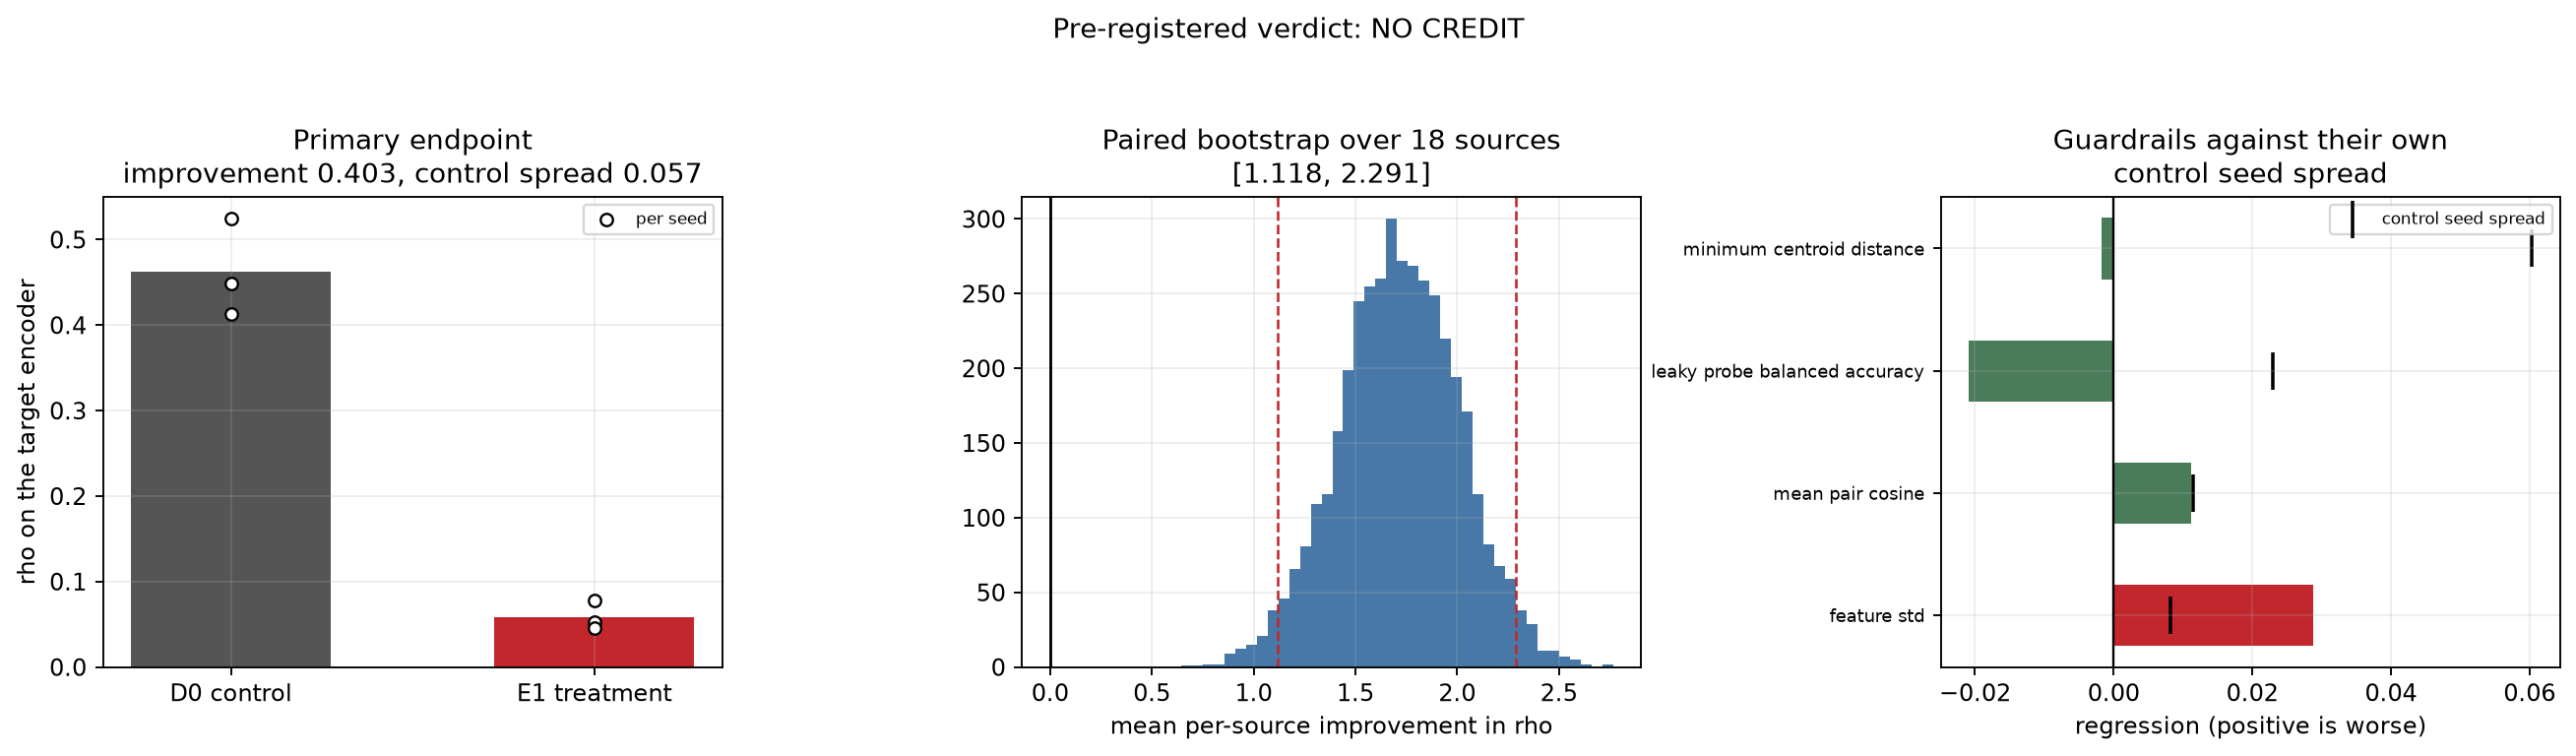

wrote /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea9_arm2/idea9_arm2_verdict.png


In [12]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

figure, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))

axes[0].bar(["D0 control", "E1 treatment"], [d0_mean, e1_mean],
            color=["#555555", "#c1272d"], width=0.55)
for x, frame in enumerate((D0, E1)):
    axes[0].scatter([x] * len(frame), frame["rho_target"], color="white", edgecolor="black",
                    zorder=3, s=28, label="per seed" if x == 0 else None)
axes[0].set_ylabel("rho on the target encoder")
axes[0].set_title(f"Primary endpoint\nimprovement {improvement:.3f}, control spread {d0_spread:.3f}")
axes[0].legend(fontsize=7)

axes[1].hist(draws, bins=40, color="#4878a8")
axes[1].axvline(0.0, color="black", lw=1.2)
axes[1].axvline(low, color="#c1272d", ls="--", lw=1.1)
axes[1].axvline(high, color="#c1272d", ls="--", lw=1.1)
axes[1].set_xlabel("mean per-source improvement in rho")
axes[1].set_title(f"Paired bootstrap over {len(sources)} sources\n[{low:.3f}, {high:.3f}]")

measurable_frame = guardrail_frame[guardrail_frame["measurable"]]
order = list(measurable_frame["guardrail"])
changes = list(measurable_frame["regression"])
spreads = list(measurable_frame["D0_seed_spread"])
positions = np.arange(len(order))
axes[2].barh(positions, changes, color=["#c1272d" if c > s else "#4a7c59"
                                        for c, s in zip(changes, spreads)], height=0.5)
axes[2].scatter(spreads, positions, marker="|", s=260, color="black", label="control seed spread")
axes[2].set_yticks(positions, [n.replace("_", " ") for n in order], fontsize=7.5)
axes[2].axvline(0.0, color="black", lw=1.0)
axes[2].set_xlabel("regression (positive is worse)")
axes[2].set_title("Guardrails against their own\ncontrol seed spread")
axes[2].legend(fontsize=7)

for axis in axes:
    axis.grid(alpha=0.22, axis="both")
figure.suptitle(f"Pre-registered verdict: {VERDICT}", y=1.04, fontsize=12)
figure.tight_layout()
verdict_png = ARM2_DIR / "idea9_arm2_verdict.png"
figure.savefig(verdict_png, dpi=170, bbox_inches="tight")
plt.close(figure)
display(Image(filename=str(verdict_png)))
print(f"wrote {verdict_png}")

In [13]:
RESULT = {
    "series": "new_nb_09", "arm": "arm2", "notebook": "new_nb_09_03",
    "mode": MODE,
    "training_scale": "real",
    "equiv_variant": sorted({b["equiv_variant"] for b in RUNGS}),
    "equiv_weight": float(E1["equiv_weight"].mean()) if len(E1) else None,
    "seeds_registered": PRE_REGISTERED["ladder"]["seeds"],
    "seeds_observed": OBSERVED_SEEDS,
    "seeds_paired": PAIRED_SEEDS,
    "protocol_deviations": DEVIATIONS,
    "evaluation_cohort": {"sequences": int(len(EVAL_XYZ)), "source_videos": int(len(set(EVAL_VIDEO))),
                          "subset": "canonical only, excluding the augmentation-normal training pool"},
    "primary": {
        "endpoint": "rho_target_encoder",
        "D0_mean": d0_mean, "D0_seed_spread": d0_spread, "E1_mean": e1_mean,
        "improvement": improvement,
        "paired_bootstrap": {"sources": int(len(sources)), "draws": BOOTSTRAP_DRAWS,
                             "mean": float(per_source_difference.mean()),
                             "median": float(np.median(per_source_difference)),
                             "ci_low": low, "ci_high": high,
                             "sources_improved": int((per_source_difference > 0).sum()),
                             "note": "per-source ratios averaged across videos; not comparable to the "
                                     "cohort-level ratio of summed terms"},
    },
    "secondary": secondary.to_dict(orient="records"),
    "guardrails": guardrail_rows,
    "guardrails_failed": guardrail_failures,
    "guardrails_not_evaluable": guardrail_unmeasurable,
    "sources_per_condition": SOURCES_PER_CONDITION,
    "degenerate_solution_check": {
        "D0_head_scale": float(D0["head_scale"].mean()),
        "E1_head_scale": float(E1["head_scale"].mean()),
        "head_grew": bool(float(E1["head_scale"].mean()) >= float(D0["head_scale"].mean())),
    },
    "credit_rule": {"condition_1_exceeds_seed_spread": condition_1,
                    "condition_2_paired_bootstrap": condition_2,
                    "condition_3_no_guardrail_regression": condition_3,
                    "all_three_required": True},
    "PRIMARY_VERDICT": VERDICT,
    "per_rung": SCORES.to_dict(orient="records"),
    "framing": PRE_REGISTERED["framing"] + [
        "rho is a symmetry property of the representation. It is not accuracy, not separation, and not "
        "clinical value. A rho improvement is not evidence of downstream benefit.",
        "The grouped condition probe is a guardrail only. Every row it scores was seen by the encoder "
        "during training, so it is transductive and is not a performance claim.",
    ],
}
result_path = ARM2_DIR / "idea9_arm2_evaluation_result.json"
result_path.write_text(json.dumps(RESULT, indent=2), encoding="utf-8")
print(f"wrote {result_path}")
print(json.dumps({"PRIMARY_VERDICT": RESULT["PRIMARY_VERDICT"],
                  "primary": {k: v for k, v in RESULT["primary"].items() if k != "paired_bootstrap"},
                  "credit_rule": RESULT["credit_rule"]}, indent=2))

wrote /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea9_arm2/idea9_arm2_evaluation_result.json
{
  "PRIMARY_VERDICT": "NO CREDIT",
  "primary": {
    "endpoint": "rho_target_encoder",
    "D0_mean": 0.46196451783180237,
    "D0_seed_spread": 0.05683479830992737,
    "E1_mean": 0.05880538125832876,
    "improvement": 0.40315913657347363
  },
  "credit_rule": {
    "condition_1_exceeds_seed_spread": true,
    "condition_2_paired_bootstrap": true,
    "condition_3_no_guardrail_regression": false,
    "all_three_required": true
  }
}


## 5. Discussion

### 5.1 The verdict is no credit, and the endpoint moved anyway

Both statements are true at the same time, and holding them together without collapsing one into the other
is the entire reason the rule was written down first.

**What did happen.** The equivariance term reaches the encoder on real data. That was genuinely open after
`new_nb_09_01`, because a term validated on a one-layer 32-dimensional toy encoder can fail at width for
reasons unrelated to its formulation. The primary endpoint fell from a control mean of 0.462 to a treatment
mean of 0.059, roughly eightfold, which is about **7.1 times** the control rung's own seed spread. **All 18
of 18 source videos improved.** The measured anatomical-mirror slope moved from -0.648 to -0.937, close to
the exact sign inversion a mirror-equivariant representation would show. Two of the three credit conditions
pass decisively.

**What also happened.** `feature_std` fell by 0.028766 against a control seed spread of 0.008185, about
3.51 times the spread, and `mean_pair_cosine` moved the same way, passing with a margin of only 0.00032
against its spread of 0.011435. Both point at one thing: the treated representation is mildly more collapsed. The rule required
all three conditions, so the verdict is **NO CREDIT**.

### 5.2 Why not simply note the caveat and call it a win

Because that is exactly the move the rule was written to prevent, and from inside the result it feels
entirely reasonable. Every ingredient for "works, with a minor caveat" is present: the endpoint improvement
is large and clean, every source video agrees, the failure is a modest change in a diagnostic, the
condition geometry is untouched, and the substitute condition probe even improves slightly.

**What makes that framing wrong is that the caveat is not independent of the effect.** The equivariance
term constrains how the encoder is allowed to respond to a body and to its reflection: it requires the two
responses to be locked together, as exact sign flips of one another along this axis. A constraint that locks
two responses together is also a constraint that **removes variance**. Shrinking feature spread is therefore
not an unrelated side effect that happens to have occurred; it is a plausible partial explanation of the
endpoint improvement itself. An encoder that has less to be inconsistent about will score better on a
consistency metric.

So there are two live accounts of the same result, and this experiment cannot separate them:

1. **The encoder learned mirror structure.** The representation now genuinely encodes the reflection
   relationship, and rho fell because the property it measures is present.
2. **The encoder lost variance in a way that happens to reduce rho.** The representation is flatter, and
   rho fell partly or wholly as a consequence of that flattening.

Nothing in this ladder distinguishes account 1 from account 2. **That is precisely why the guardrail was
registered in advance.** It was not registered because someone expected it to fail; it was registered
because its failure would be informative in exactly this way, and because a guardrail invented after seeing
a result cannot carry that information at all. The negative verdict here is the preregistration working as
designed, not a technicality obstructing an otherwise good result.

**What the head-scale check does and does not buy.** `new_nb_09_01` showed the registered loss form has a
degenerate solution in which the readout shrinks and the encoder is untouched. Here the head's output scale
**grew**, from 0.748023 to 1.058683, so the endpoint did not improve by the readout collapsing and that
specific fixture-identified failure mode is ruled out on real data. It does **not** rule out the milder
variance-removal account above, and conflating the two would overstate the check considerably. Ruling out
the readout collapsing is not the same as ruling out the representation flattening.

### 5.3 What is not established at all

**rho is a symmetry property of the representation. It is not accuracy, it is not class separation, and it
is not clinical value.** A representation can be perfectly mirror-equivariant and useless for gait
assessment, and this ladder cannot distinguish those cases. An improvement in rho is not evidence of
downstream benefit. The one endpoint here that would have spoken to downstream benefit, the antisymmetric
lane R-squared, did not improve at all, going from -0.027234 to -0.029977, and it sits behind a failed
quality gate that makes it uninterpretable in either direction anyway.

The guardrails are shaped to detect damage rather than to demonstrate benefit, so even a clean sweep on all
three would not have shown that the term helps anything.

**One registered guardrail could not be evaluated,** and the distinction matters: it is **not evaluable**,
never failed. A source-grouped five-class probe needs at least two source videos per condition, and all 12
canonical normal sequences come from a single video, so a source-grouped fold would be asked to recognise a
condition it has no examples of. The substitute is a stratified probe that leaks video identity across
folds, which is adequate for noticing destruction and worthless as evidence about conditions. Its slight
improvement supports no condition claim.

**The transductive boundary is unchanged.** The encoder saw every evaluation sequence during training, on
both rungs equally. That is acceptable for a control-versus-treatment contrast, which is what this is, and
it remains disqualifying for any claim about an unseen patient, camera, or clinic. Folder labels are dataset
annotations, not clinical diagnoses, and the source video, not the sequence, is the independent unit of
evidence throughout.

**And the ladder ran 3 seeds against 5 registered.** The effect measured was large enough that three seeds
could read it, but the yardstick in condition 1 rests on a standard deviation estimated from three values,
and a marginal effect could not have been adjudicated here at all.

### 5.4 What the three notebooks before this one bought

Four specific errors were avoided. Each was cheap to catch where it was caught and would have been expensive
or impossible to catch later.

**The no-op.** A head-only formulation of the equivariance term is identically zero for an antisymmetric
head, so it trains nothing while looking like a constraint. Measuring the gradient rather than reasoning
about it took one cell in `new_nb_09_01`.

**The degenerate solution.** The term as registered is minimised by shrinking the readout, and its loss
curve falls by more than two orders of magnitude while the encoder is unchanged: on fixtures the term fell
184.16-fold while the head's signal shrank 4.77-fold and rho moved by 0.0096 against a gate of 0.0492. Had
the real ladder run that form, it would have consumed the full compute budget and produced a confident,
wrong, positive result supported by a beautiful loss curve.

**The endpoint choice.** Arm 1's own preregistered gate recorded that the labelled target's between-source
variance fraction was 0.0747 against a required 0.30, which makes a held-out-source R-squared
uninterpretable on this cohort. Scoring this ladder on R-squared would have produced a number that could not
support a conclusion in either direction, and the temptation to read one anyway would have been considerable.

**The fixture extrapolation.** The fixtures in `new_nb_09_01` sit near rho 3.9 because their toy encoder is
mirror-blind by construction, and it was tempting to read that as a forecast for real encoders. The real
control rungs average rho 0.462 on the target encoder, far closer to mirror-honest. A fixture can establish
that a measurement means what you claim while telling you nothing about where real data will fall on it, and
conflating those two roles is easiest when the fixture number is memorable.

### 5.5 The joint conclusion: three experiments, three different epistemic states

Idea 5 and the two arms of Idea 9 do **not** say the same thing, and collapsing them into "it did not work"
loses most of what was learned.

| Experiment | What it changed | Endpoint | Verdict | What the verdict means |
|---|---|---|---|---|
| Idea 5, `nb_05a` | nothing; read out of the frozen encoder | ridge R2 on a signed target | **INFORMATIVE NULL** | the measurement was valid and the answer was no |
| Idea 9 arm 1, `nb_09a` | the readout's shape only; encoder still frozen | ridge R2 on a signed target | **ARTIFACT** | the lane is not admissible evidence about sides at all |
| Idea 9 arm 2, this series | the encoder itself, during the full curriculum | label-free rho | **NO CREDIT** | the effect is real but a registered guardrail supplies a competing explanation |

1. **Idea 5's informative null** means the measurement was valid and the answer was no: no linearly
   decodable signed laterality axis above a raw-coordinate baseline or an untrained-encoder floor.
2. **Arm 1's artifact** means the measurement was not admissible evidence about sides at all, because a
   mirror-symmetrized lane that is mathematically blind to left and right outscored the antisymmetric
   treatment. The claim is **withdrawn rather than answered**, which is a **weaker** epistemic state than a
   null, not a stronger one.
3. **Arm 2's no credit** means the effect is real, large, and consistent across every one of the 18 source
   videos, but a preregistered guardrail failed and its failure supplies a competing explanation for the
   effect, so the effect is not credited.

**Each experiment closed a specific escape route from the previous one.** Idea 5 could have failed because
the readout had the wrong shape, so arm 1 built an antisymmetric-by-construction head and verified its
wiring at exactly -1; the null survived. Arm 1 could have failed because the encoder was never asked to
respect the mirror, so arm 2 asked it directly and drove rho to 0.0588; so incapacity was never the
explanation either. The encoder can be made mirror-consistent. That was worth knowing and it is now known.

**The binding constraint is the cohort, not the model and not the readout.** There are 18 independent source
videos, and only about 7.5 percent of the labelled target's variance lies between them against a
preregistered 30 percent. That measurement belongs to **arm 1, `nb_09a`**, and it explains Idea 5's null and
arm 1's artifact at the same time. Source-disjoint folds hold out nearly all of the usable signal by
construction. Arm 2's label-free rho sidesteps that limit for the symmetry property, and nothing in this
package sidesteps it for a labelled clinical target.

**In all three experiments the informative element is a control, not the treatment**: the untrained-encoder
floor in Idea 5, the side-blind lane E in arm 1, and the feature-spread guardrail here. Report the ladders,
not just the headlines.

**What none of the three licenses.** No clinical claim. No statement about unseen videos. No equating of rho
with performance or with condition separation. Every score in this family is transductive.

### 5.6 What to do next

Two steps follow, in this order.

**First, separate the two explanations of the endpoint improvement.** A sweep over `equiv_weight` would show
whether feature spread and endpoint gain move together across weights, which is what the variance-removal
account predicts, or whether there is a weight at which the endpoint improves while spread holds, which the
mirror-structure account allows. That is a cheap experiment on the existing recipe and it decides how the
current result should be read. Until it is run, the verdict here should stay at no credit rather than being
softened.

**Second, ask whether the property is worth having at all.** Score the treatment and control checkpoints on
a task with an interpretable endpoint and enough independent sources to support it. That needs either a
target whose between-source variance clears the 0.30 gate, or a cohort with enough source videos that the
existing target does.

The second route leads back to the same conclusion arm 1 reached from the other direction. The binding
constraint on this line of work is the number of independent source videos, and not the readout, the loss, or
the head. That is a data-collection finding rather than a modelling one, and it is more actionable than
another architecture would have been.
